In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

In [2]:
loyalty = pd.read_csv("/home/arka/Airline_Loyalty_Analytics/data/Customer Loyalty History.csv")
flight = pd.read_csv("/home/arka/Airline_Loyalty_Analytics/data/Customer Flight Activity.csv")
calendar = pd.read_csv("/home/arka/Airline_Loyalty_Analytics/data/Calendar.csv")

In [3]:
customer_features = flight.groupby(
    'Loyalty Number'
).agg({
    'Total Flights': 'sum',
    'Distance': 'sum',
    'Points Accumulated': 'sum',
    'Points Redeemed': 'sum',
    'Dollar Cost Points Redeemed': 'sum'
}).reset_index()

In [4]:
customer_features.head()

,Loyalty Number,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed
0,100018,46,81190,81190.0,1513,272
1,100102,51,68918,68918.0,1195,215
2,100140,47,72856,72856.0,593,107
3,100214,22,38236,38236.0,861,155
4,100272,37,54997,54997.0,1007,182


In [5]:
customer_features = customer_features.merge(
    loyalty,
    on='Loyalty Number',
    how='left'
)

In [6]:
customer_features.shape

(16737, 21)

In [7]:
customer_features['Loyalty_Age'] = (
    2018 - 
    customer_features['Enrollment Year']
)

In [8]:
customer_features['Redemption_Rate'] = (
    customer_features['Points Redeemed']
    /
    customer_features['Points Accumulated']
)

In [9]:
customer_features['Redemption_Rate'] = (
    customer_features['Redemption_Rate']
    .replace([np.inf,-np.inf],0)
    .fillna(0)
)

In [10]:
customer_features[
    [
        'Total Flights',
        'Distance',
        'Points Accumulated',
        'Points Redeemed',
        'Redemption_Rate',
        'Loyalty_Age'
    ]
    ].describe()

,Total Flights,Distance,Points Accumulated,Points Redeemed,Redemption_Rate,Loyalty_Age
count,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000,16737.000000
mean,30.400191,45579.359921,47592.100884,734.932903,0.016147,2.746789
std,16.865558,26092.338663,30391.859064,716.589736,0.025660,1.979111
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,20.000000,28495.000000,28718.000000,0.000000,0.000000,1.000000
50%,34.000000,49445.000000,49885.000000,568.000000,0.011838,3.000000
75%,42.000000,62911.000000,63812.000000,1167.000000,0.023417,4.000000
max,106.000000,178858.000000,268287.000000,4479.000000,1.194352,6.000000


In [11]:
customer_features.head()

,Loyalty Number,Total Flights,Distance,Points Accumulated,Points Redeemed,Dollar Cost Points Redeemed,Country,Province,City,Postal Code,Gender,Education,Salary,Marital Status,Loyalty Card,CLV,Enrollment Type,Enrollment Year,Enrollment Month,Cancellation Year,Cancellation Month,Loyalty_Age,Redemption_Rate
0,100018,46,81190,81190.0,1513,272,Canada,Alberta,Edmonton,T9G 1W3,Female,Bachelor,92552.0,Married,Aurora,7919.20,Standard,2016,8,NaN,NaN,2,0.018635
1,100102,51,68918,68918.0,1195,215,Canada,Ontario,Toronto,M1R 4K3,Male,College,NaN,Single,Nova,2887.74,Standard,2013,3,NaN,NaN,5,0.017339
2,100140,47,72856,72856.0,593,107,Canada,British Columbia,Dawson Creek,U5I 4F1,Female,College,NaN,Divorced,Nova,2838.07,Standard,2016,7,NaN,NaN,2,0.008139
3,100214,22,38236,38236.0,861,155,Canada,British Columbia,Vancouver,V5R 1W3,Male,Bachelor,63253.0,Married,Star,4170.57,Standard,2015,8,NaN,NaN,3,0.022518
4,100272,37,54997,54997.0,1007,182,Canada,Ontario,Toronto,P1L 8X8,Female,Bachelor,91163.0,Divorced,Star,6622.05,Standard,2014,1,NaN,NaN,4,0.018310


In [12]:
customer_features.columns.tolist()

['Loyalty Number',
 'Total Flights',
 'Distance',
 'Points Accumulated',
 'Points Redeemed',
 'Dollar Cost Points Redeemed',
 'Country',
 'Province',
 'City',
 'Postal Code',
 'Gender',
 'Education',
 'Salary',
 'Marital Status',
 'Loyalty Card',
 'CLV',
 'Enrollment Type',
 'Enrollment Year',
 'Enrollment Month',
 'Cancellation Year',
 'Cancellation Month',
 'Loyalty_Age',
 'Redemption_Rate']

In [13]:
flight['Activity_Date'] = pd.to_datetime(
    flight['Year'].astype(str) + '-' +
    flight['Month'].astype(str)+ '-01'
)

In [14]:
active_flights = flight[
    flight['Total Flights']>0
    ].copy()

In [15]:
last_flight = (
    active_flights
    .groupby('Loyalty Number')['Activity_Date']
    .max()
    .reset_index()
)

In [16]:
last_flight.columns = [
    'Loyalty Number',
    'Last_Flight_Date'
]

In [17]:
snapshot_date = pd.Timestamp('2018-12-01')

In [18]:
last_flight['Recency_Months'] = (
    (
        snapshot_date - 
        last_flight['Last_Flight_Date']
    ).dt.days
    /30
).round()

In [19]:
customer_features = customer_features.merge(
    last_flight,
    on='Loyalty Number',
    how='left'
)

In [20]:
customer_features['Recency_Months'] = (
    customer_features['Recency_Months']
    .fillna(24)
)

In [21]:
customer_features['Recency_Months'].describe()

count    16737.000000
mean         3.561929
std          7.375618
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         24.000000
Name: Recency_Months, dtype: float64

In [22]:
customer_features[
    [
        'Loyalty Number',
        'Total Flights',
        'Recency_Months'
    ]
    ].head(10)

,Loyalty Number,Total Flights,Recency_Months
0,100018,46,0.0
1,100102,51,0.0
2,100140,47,1.0
3,100214,22,0.0
4,100272,37,1.0
5,100301,41,0.0
6,100364,33,0.0
7,100380,33,0.0
8,100428,35,0.0
9,100504,19,10.0


In [23]:
customer_features['Churn'] = np.where(
    (
        customer_features['Recency_Months'] >= 6
    ) |
    (
        customer_features['Cancellation Year'].notna()
    ),
    1,
    0
)

In [24]:
customer_features['Churn'].value_counts()

Churn
0    13943
1     2794
Name: count, dtype: int64

In [25]:
customer_features['Churn'].value_counts(normalize=True)*100

Churn
0    83.306447
1    16.693553
Name: proportion, dtype: float64

In [26]:
customer_features['Avg_Monthly_Flights'] = (
     customer_features['Total Flights']/24
)

In [27]:
customer_features['Engagement_Score'] = (
    customer_features['Redemption_Rate']*100
)

In [28]:
customer_features['Distance_Per_Flight'] = (
    customer_features['Distance'] /
    customer_features['Total Flights']
)
customer_features['Distance_Per_Flight'] = (
    customer_features['Distance_Per_Flight']
    .replace([np.inf, -np.inf], 0)
    .fillna(0)
)

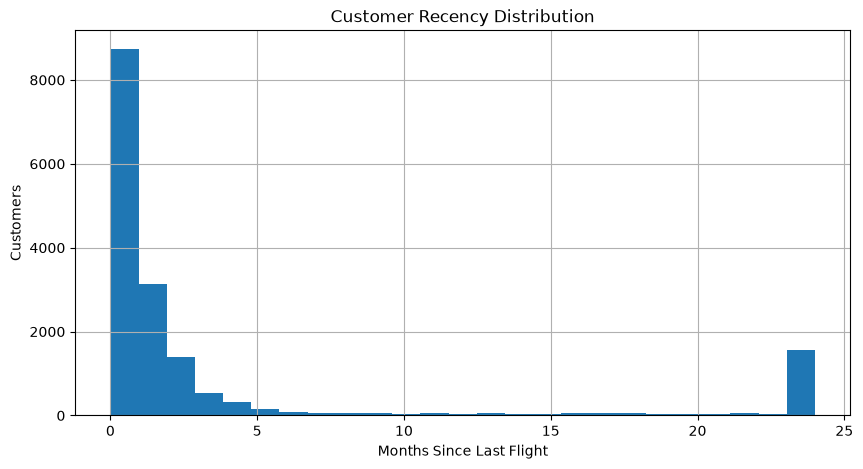

In [29]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
customer_features['Recency_Months'].hist(
    bins=25
)
plt.title(
    'Customer Recency Distribution'
)
plt.xlabel('Months Since Last Flight')
plt.ylabel('Customers')
plt.show()

In [30]:
customer_features.groupby('Churn')[
    [
        'Total Flights',
        'Distance',
        'Points Accumulated',
        'Points Redeemed',
        'CLV',
        'Recency_Months'
    ]
    ].mean().round(2)

,Total Flights,Distance,Points Accumulated,Points Redeemed,CLV,Recency_Months
Churn,,,,,,
0,34.84,52216.15,54380.12,844.72,7967.12,0.62
1,8.26,12459.53,13717.58,187.05,8097.57,18.24


In [31]:
segmentation_features = customer_features[
    [
        'Avg_Monthly_Flights',
        'Total Flights',
        'Distance_Per_Flight',
        'Points Accumulated',
        'Points Redeemed',
        'Redemption_Rate',
        'CLV',
        'Recency_Months'
    ]
    ]

In [32]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(
    segmentation_features
)

In [33]:
from sklearn.cluster import KMeans
inertia = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

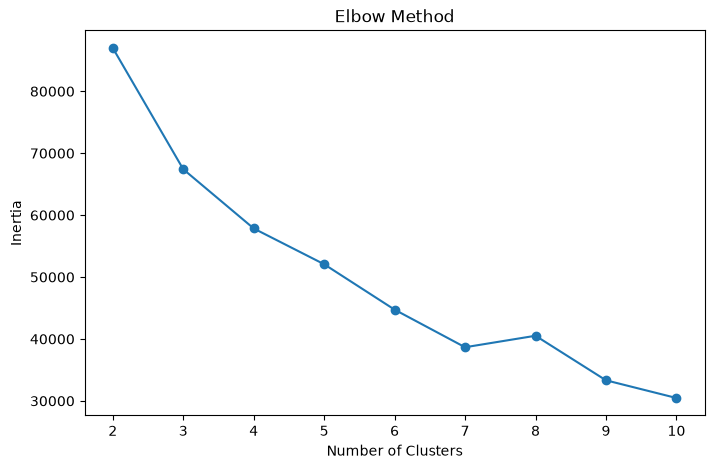

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    inertia,
    marker='o'
)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [35]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)
customer_features['Cluster'] = kmeans.fit_predict(
    scaled_features
)

In [36]:
cluster_profile = customer_features.groupby(
    'Cluster'
)[
[
    'Total Flights',
    'Distance',
    'Points Accumulated',
    'Points Redeemed',
    'Redemption_Rate',
    'Recency_Months',
    'CLV',
    'Loyalty_Age'
]
].mean().round(2)

cluster_profile

,Total Flights,Distance,Points Accumulated,Points Redeemed,Redemption_Rate,Recency_Months,CLV,Loyalty_Age
Cluster,,,,,,,,
0,15.92,23613.09,23872.53,312.08,0.02,3.21,7927.77,1.42
1,42.42,64101.97,68969.05,542.14,0.01,0.63,7887.20,3.08
2,0.14,146.82,146.82,3.29,0.00,23.89,8330.72,3.06
3,36.85,54767.47,54916.93,1662.59,0.03,0.78,8068.27,3.34


In [37]:
customer_features['Cluster'].value_counts()

Cluster
1    6568
3    4495
0    4041
2    1633
Name: count, dtype: int64

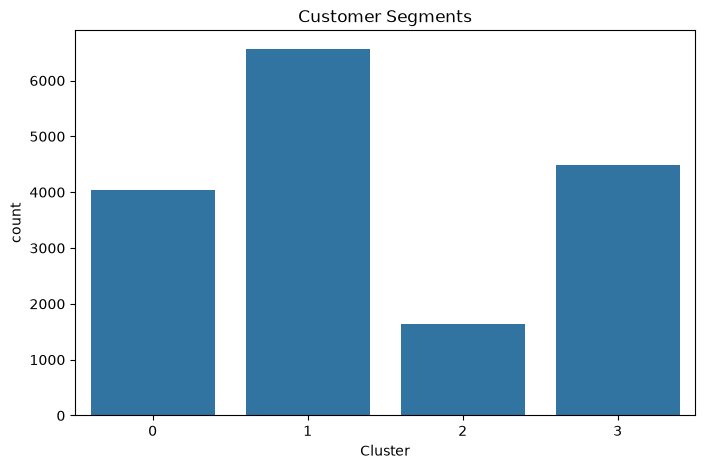

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
sns.countplot(x='Cluster', data=customer_features)
plt.title('Customer Segments')
plt.show()

In [39]:
cluster_name = {
    0: 'Champions',
    1: 'Dormant Members',
    2: 'Growth Travelers',
    3: 'Loyalty Enthusiasts'
}

customer_features['Segment'] = (
    customer_features['Cluster']
    .map(cluster_name)
)

In [40]:
customer_features['Segment'].value_counts()

Segment
Dormant Members        6568
Loyalty Enthusiasts    4495
Champions              4041
Growth Travelers       1633
Name: count, dtype: int64

In [41]:
pd.crosstab(
    customer_features['Segment'],
    customer_features['Churn'],
    normalize='index'
)*100

Churn,0,1
Segment,,
Champions,78.346944,21.653056
Dormant Members,97.381242,2.618758
Growth Travelers,0.000000,100.000000
Loyalty Enthusiasts,97.463849,2.536151


In [42]:
model_data = customer_features.copy()

In [43]:
drop_cols = [
    'Loyalty Number',
    'Cancellation Year',
    'Cancellation Month',
    'Cluster',
    'Segment',
    'Last_Flight_Date'
]
model_data = model_data.drop(
    columns=drop_cols,
    errors='ignore'
)

In [44]:
model_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 16737 entries, 0 to 16736
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Total Flights                16737 non-null  int64  
 1   Distance                     16737 non-null  int64  
 2   Points Accumulated           16737 non-null  float64
 3   Points Redeemed              16737 non-null  int64  
 4   Dollar Cost Points Redeemed  16737 non-null  int64  
 5   Country                      16737 non-null  str    
 6   Province                     16737 non-null  str    
 7   City                         16737 non-null  str    
 8   Postal Code                  16737 non-null  str    
 9   Gender                       16737 non-null  str    
 10  Education                    16737 non-null  str    
 11  Salary                       12499 non-null  float64
 12  Marital Status               16737 non-null  str    
 13  Loyalty Card               

In [45]:
model_data['Salary_Missing'] = (
    model_data['Salary']
    .isna()
    .astype(int)
)

model_data['Salary'] = (
    model_data['Salary']
    .fillna(
        model_data['Salary'].median()
    )
)

In [46]:
model_data = model_data.drop(
    columns=['Postal Code']
)

In [47]:
model_data = model_data.drop(
    columns=['City']
)

In [48]:
X = model_data.drop(
    columns=['Churn']
)

y = model_data['Churn']

In [49]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state=42,
    stratify=y
)

In [50]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [51]:
cat_cols = X.select_dtypes(
    include='object'
).columns

num_cols = X.select_dtypes(
    exclude='object'
).columns

/tmp/ipykernel_7173/1358093718.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(


In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols
        ),
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            cat_cols
        )
    ]
)

In [53]:
from sklearn.linear_model import LogisticRegression
logistic_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier',
     LogisticRegression(
         max_iter=2000
     ))
])

In [54]:
logistic_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Total Flights','Distance','Points Accumulated',...,'Engagement_Score', 'Distance_Per_Flight','Salary_Missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [55]:
print(type(y))
print(y.shape)

<class 'pandas.Series'>
(16737,)


In [56]:
print(type(y_train))
print(y_train.shape)

<class 'pandas.Series'>
(13389,)


In [57]:
print(X.shape)
print(y.shape)

(16737, 23)
(16737,)


In [58]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X shape: (16737, 23)
y shape: (16737,)
X_train: (13389, 23)
X_test: (3348, 23)
y_train: (13389,)
y_test: (3348,)


In [59]:
y_pred = logistic_model.predict(X_test)

In [60]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
print("Accuracy: ", accuracy_score(y_test, y_pred))
print("Precision: ", precision_score(y_test, y_pred))
print("Recall: ", recall_score(y_test, y_pred))
print("F1 Score: ", f1_score(y_test, y_pred))

Accuracy:  0.9802867383512545
Precision:  0.97678916827853
Recall:  0.9033989266547406
F1 Score:  0.9386617100371747


In [61]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[2777   12]
 [  54  505]]


In [62]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      2789
           1       0.98      0.90      0.94       559

    accuracy                           0.98      3348
   macro avg       0.98      0.95      0.96      3348
weighted avg       0.98      0.98      0.98      3348



In [63]:
feature_names = (
    logistic_model.named_steps['preprocessor']
    .get_feature_names_out()
)

coefficients = (
    logistic_model.named_steps['classifier']
    .coef_[0]
)

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance['Abs_Coefficient'] = (
    importance['Coefficient']
    .abs()
)

importance = importance.sort_values(
    'Abs_Coefficient',
    ascending=False
)

importance.head(20)

,Feature,Coefficient,Abs_Coefficient
11,num__Recency_Months,8.143123,8.143123
42,cat__Enrollment Type_Standard,-0.960748,0.960748
41,cat__Enrollment Type_2018 Promotion,0.721971,0.721971
22,cat__Province_Nova Scotia,-0.656220,0.656220
33,cat__Education_High School or Below,-0.530221,0.530221
34,cat__Education_Master,0.406780,0.406780
27,cat__Province_Yukon,0.386744,0.386744
20,cat__Province_New Brunswick,-0.333980,0.333980
2,num__Points Accumulated,0.332152,0.332152
21,cat__Province_Newfoundland,0.309438,0.309438


In [64]:
X_no_recency = model_data.drop(columns=['Churn', 'Recency_Months'])
y=model_data['Churn']

In [65]:
print(X_no_recency.shape)

(16737, 22)


In [66]:
from sklearn.model_selection import train_test_split
X_train_nr, X_test_nr, y_train_nr, y_test_nr = train_test_split(X_no_recency, y, test_size=0.2, random_state=42, stratify=y)

In [67]:
print(X_train_nr.shape)
print(X_test_nr.shape)
print(y_train_nr.shape)
print(y_test_nr.shape)

(13389, 22)
(3348, 22)
(13389,)
(3348,)


In [68]:
cat_cols_nr = X_no_recency.select_dtypes(
    include='object'
).columns

num_cols_nr = X_no_recency.select_dtypes(
    exclude='object'
).columns

/tmp/ipykernel_7173/4103180350.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols_nr = X_no_recency.select_dtypes(


In [69]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

preprocessor_nr = ColumnTransformer(
    transformers=[
        (
            'num',
            StandardScaler(),
            num_cols_nr
        ),
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            cat_cols_nr
        )
    ]
)

In [70]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_nr = Pipeline([
    ('preprocessor', preprocessor_nr),
    (
        'classifier',
        LogisticRegression(
            max_iter=2000
        )
    )
])

In [71]:
logistic_nr.fit(
    X_train_nr,
    y_train_nr
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](22,)","['Total Flights','Distance','Points Accumulated',...,'Engagement_Score', 'Distance_Per_Flight','Salary_Missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,22
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [72]:
y_pred_nr = logistic_nr.predict(
    X_test_nr
)

In [73]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("Accuracy :", accuracy_score(y_test_nr, y_pred_nr))
print("Precision:", precision_score(y_test_nr, y_pred_nr))
print("Recall   :", recall_score(y_test_nr, y_pred_nr))
print("F1 Score :", f1_score(y_test_nr, y_pred_nr))

Accuracy : 0.9307048984468339
Precision: 0.9017199017199017
Recall   : 0.6565295169946332
F1 Score : 0.7598343685300207


In [74]:
from sklearn.metrics import confusion_matrix

cm_nr = confusion_matrix(
    y_test_nr,
    y_pred_nr
)

print(cm_nr)

[[2749   40]
 [ 192  367]]


In [75]:
from sklearn.ensemble import RandomForestClassifier

In [76]:
rf_model = Pipeline([
    ('preprocessor', preprocessor),
    (
        'classifier',
        RandomForestClassifier(
            n_estimators=300,
            max_depth=10,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [77]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['Total Flights','Distance','Points Accumulated',...,'Engagement_Score', 'Distance_Per_Flight','Salary_Missing']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).B

In [78]:
rf_pred = rf_model.predict(X_test)

In [79]:
print("Accuracy:",accuracy_score(y_test, rf_pred))
print("Precision:",precision_score(y_test, rf_pred))
print("Recall:",recall_score(y_test, rf_pred))
print("F1:",f1_score(y_test, rf_pred))

Accuracy: 0.9835722819593787
Precision: 0.9980237154150198
Recall: 0.9033989266547406
F1: 0.9483568075117371


In [80]:
print(confusion_matrix(y_test, rf_pred))

[[2788    1]
 [  54  505]]


In [81]:
feature_names = (rf_model.named_steps['preprocessor'].get_feature_names_out())
importances = ( rf_model.named_steps['classifier'].feature_importances_)
rf_importance = pd.DataFrame({'Feature': feature_names,'Importance': importances})
rf_importance = rf_importance.sort_values('Importance',ascending=False)
rf_importance.head(20)

,Feature,Importance
11,num__Recency_Months,0.336978
12,num__Avg_Monthly_Flights,0.119040
1,num__Distance,0.106654
14,num__Distance_Per_Flight,0.103215
0,num__Total Flights,0.096612
2,num__Points Accumulated,0.094581
10,num__Redemption_Rate,0.021474
7,num__Enrollment Year,0.020519
13,num__Engagement_Score,0.020100
9,num__Loyalty_Age,0.018052


In [82]:
rf_probs = rf_model.predict_proba(X)[:,1]

In [83]:
customer_features['Churn_Probability'] = rf_probs

In [85]:
customer_features[['Segment', 'Churn_Probability']].head()

,Segment,Churn_Probability
0,Loyalty Enthusiasts,0.007624
1,Dormant Members,0.007680
2,Dormant Members,0.010019
3,Champions,0.021974
4,Dormant Members,0.008009


In [86]:
customer_features['Priority_Level'] = pd.cut(customer_features['Retention_Priority'], bins=[0,0.3,0.6,1], labels=['Low','Medium','High'])

KeyError: 'Retention_Priority'

In [87]:
'Churn_Probability' in customer_features.columns

True

In [88]:
print(X.shape)
print(customer_features.shape)

(16737, 23)
(16737, 32)


In [89]:
print(rf_probs.shape)

(16737,)


In [91]:
customer_features['Retention_Priority'] = (
    customer_features['Churn_Probability'] * 0.6
    + (customer_features['CLV']
       / customer_features['CLV'].max()) * 0.4
)

In [93]:
customer_features[
    ['Churn_Probability',
     'CLV',
     'Retention_Priority']
    ].head()

,Churn_Probability,CLV,Retention_Priority
0,0.007624,7919.20,0.042590
1,0.007680,2887.74,0.018470
2,0.010019,2838.07,0.019636
3,0.021974,4170.57,0.033205
4,0.008009,6622.05,0.036594


In [94]:
customer_features['Priority_Level'] = pd.cut(
    customer_features['Retention_Priority'],
    bins=[0,0.3,0.6,1],
    labels=['Low','Medium','High']
)

In [95]:
customer_features['Priority_Level'].value_counts()

Priority_Level
Low       14158
High       1864
Medium      715
Name: count, dtype: int64

In [96]:
segment_weight = {
    'Champions': 1.0,
    'Growth Travelers': 0.8,
    'Loyalty Enthusiasts': 0.7,
    'Dormant Members': 0.5
}

customer_features['Segment_Weight'] = (
    customer_features['Segment']
    .map(segment_weight)
)

customer_features['Retention_Priority'] = (
      customer_features['Churn_Probability'] * 0.5
    + (customer_features['CLV'] /
       customer_features['CLV'].max()) * 0.3
    + customer_features['Segment_Weight'] * 0.2
)

In [97]:
customer_features['Priority_Level'] = pd.cut(
    customer_features['Retention_Priority'],
    bins=[0,0.3,0.6,1],
    labels=['Low','Medium','High']
)

customer_features['Priority_Level'].value_counts()

Priority_Level
Low       13806
High       2387
Medium      544
Name: count, dtype: int64

In [100]:
customer_features.groupby(
    'Priority_Level'
)[
[
    'Churn_Probability',
    'CLV',
    'Retention_Priority',
]
].mean().round(3)

,Churn_Probability,CLV,Retention_Priority
Priority_Level,,,
Low,0.022,7586.313,0.172
Medium,0.326,17100.985,0.399
High,0.969,8240.716,0.687


In [101]:
def recommend_action(row):

    if row['Segment'] == 'Champions':
        return 'Offer Premium Upgrade'

    elif row['Segment'] == 'Growth Travelers':
        return 'Provide Tier Acceleration Bonus'

    elif row['Segment'] == 'Loyalty Enthusiasts':
        return 'Promote Reward Redemption Campaign'

    elif row['Segment'] == 'Dormant Members':
        return 'Launch Win-Back Offer'

    return 'General Engagement Campaign'


customer_features['Recommended_Action'] = (
    customer_features.apply(
        recommend_action,
        axis=1
    )
)

In [107]:
top_customers = customer_features.sort_values(
    'Retention_Priority',
    ascending=False
)[
    [
        'Loyalty Number',
        'Segment',
        'Churn_Probability',
        'CLV',
        'Priority_Level',
        'Recommended_Action'
    ]
]
top_customers.head(20)

,Loyalty Number,Segment,Churn_Probability,CLV,Priority_Level,Recommended_Action
10297,652627,Growth Travelers,1.000000,83325.38,High,Provide Tier Acceleration Bonus
12468,767366,Champions,0.930650,73225.96,High,Offer Premium Upgrade
13888,844145,Growth Travelers,1.000000,74228.52,High,Provide Tier Acceleration Bonus
13776,838263,Growth Travelers,1.000000,67907.27,High,Provide Tier Acceleration Bonus
10672,672917,Growth Travelers,1.000000,58166.55,High,Provide Tier Acceleration Bonus
11873,737027,Growth Travelers,1.000000,49221.43,High,Provide Tier Acceleration Bonus
7976,529331,Growth Travelers,1.000000,49221.43,High,Provide Tier Acceleration Bonus
15685,943393,Growth Travelers,1.000000,48356.96,High,Provide Tier Acceleration Bonus
16199,969719,Champions,0.968221,40235.97,High,Offer Premium Upgrade
2894,257194,Growth Travelers,0.999931,46770.95,High,Provide Tier Acceleration Bonus


In [108]:
customer_features.groupby(
    'Segment'
)[
    [
        'CLV',
        'Churn_Probability',
        'Retention_Priority'
    ]
    ].mean().round(3)

,CLV,Churn_Probability,Retention_Priority
Segment,,,
Champions,7927.766,0.214,0.335
Dormant Members,7887.198,0.028,0.143
Growth Travelers,8330.722,0.999,0.690
Loyalty Enthusiasts,8068.270,0.026,0.182


In [109]:
pd.crosstab(
    customer_features['Segment'],
    customer_features['Priority_Level'],
    normalize='index'
)*100

Priority_Level,Low,Medium,High
Segment,,,
Champions,72.407820,9.205642,18.386538
Dormant Members,98.614495,1.370280,0.015225
Growth Travelers,0.000000,0.000000,100.000000
Loyalty Enthusiasts,97.953281,1.824249,0.222469


In [110]:
customer_features.groupby(
    'Segment'
)[
    [
        'Recency_Months',
        'Total Flights',
        'Avg_Monthly_Flights'
    ]
    ].mean().round(2)

,Recency_Months,Total Flights,Avg_Monthly_Flights
Segment,,,
Champions,3.21,15.92,0.66
Dormant Members,0.63,42.42,1.77
Growth Travelers,23.89,0.14,0.01
Loyalty Enthusiasts,0.78,36.85,1.54


In [111]:
new_names = {
    'Champions': 'Active Travelers',
    'Dormant Members': 'Champions',
    'Growth Travelers': 'Dormant Members',
    'Loyalty Enthusiasts': 'Loyalty Enthusiasts'
}

In [112]:
customer_features['Segment'] = (
    customer_features['Segment']
    .replace(new_names)
)

In [113]:
customer_features['Segment'].value_counts()

Segment
Champions              6568
Loyalty Enthusiasts    4495
Active Travelers       4041
Dormant Members        1633
Name: count, dtype: int64

In [114]:
customer_features.to_csv(
    'customer_intelligence_dataset.csv',
    index=False
)